# Simulate freezing

We need a few imports:

In [1]:
import matplotlib.pyplot as plt
from matplotlib import rc as matplotlibrc
from ruamel.yaml import YAML
yaml = YAML()

from lyopronto import freezing, plot_styling

Then, we provide all the necessary simulation parameters.

In [2]:
# Set up the simulation settings
# This needs to be a dict with string keys, which can be expressed in YAML as well
sim = yaml.load("""
tool: Freezing Calculator
Kv_known: Y
Rp_known: Y
Variable_Pch: N
Variable_Tsh: N
""")
# Or, equivalently:
sim = {
    'tool': 'Freezing Calculator',
    'Kv_known': 'Y',
    'Rp_known': 'Y',
    'Variable_Pch': 'N',
    'Variable_Tsh': 'N'
}


# Vial and fill properties
vial = {
    # Av = Vial area in cm^2
    'Av': 3.80,
    # Ap = Product Area in cm^2
    'Ap': 3.14,
    # Vfill = Fill volume in mL
    'Vfill': 2.0
}

In [3]:
# Product properties for freezing
product = {
    # cSolid = Fractional concentration of solute in the frozen solution
    'cSolid': 0.0,
    # Initial product temperature
    'Tpr0': 15.8,  # in deg C
    # Freezing temperature
    'Tf': -1.54,  # in deg C
    # Nucleation temperature
    'Tn': -5.84,  # in deg C
    # Critical product temperature
    # At least 2 to 3 deg C below collapse or glass transition temperature
    'T_pr_crit': -5  # in deg C
}

In [4]:
# Shelf temperature profile
Tshelf = {
    # init = Initial shelf temperature in C
    'init': 15.0,
    # setpt = Shelf temperature set points in C
    'setpt': [-40.0],
    # dt_setpt = Time for which shelf temperature set points are held in min
    'dt_setpt': [180.0],
    # ramp_rate = Shelf temperature ramping rate in C/min
    'ramp_rate': 1.0
}

In [5]:
# Time step
dt = 0.01    # hr

# Equipment capability parameters (not used for freezing, but included for completeness)
eq_cap = {
    'a': -0.182,  # kg/hr
    'b': 11.7     # kg/hr/Torr
}

# Number of vials (not used for freezing, but included for completeness)
nVial = 398

# Freezing heat transfer coefficient
h_freezing = 38.0  # W/m^2/K

Now, we are ready to actually run the simulation, which is `lyopronto.freezing.freeze`.

??? info - documentation
    *Here is the docstring for `freezing.freeze`:*
    ::: lyopronto.freezing.freeze

In [6]:
output_table = freezing.freeze(vial, product, h_freezing, Tshelf, dt)

Now, let's plot the results.

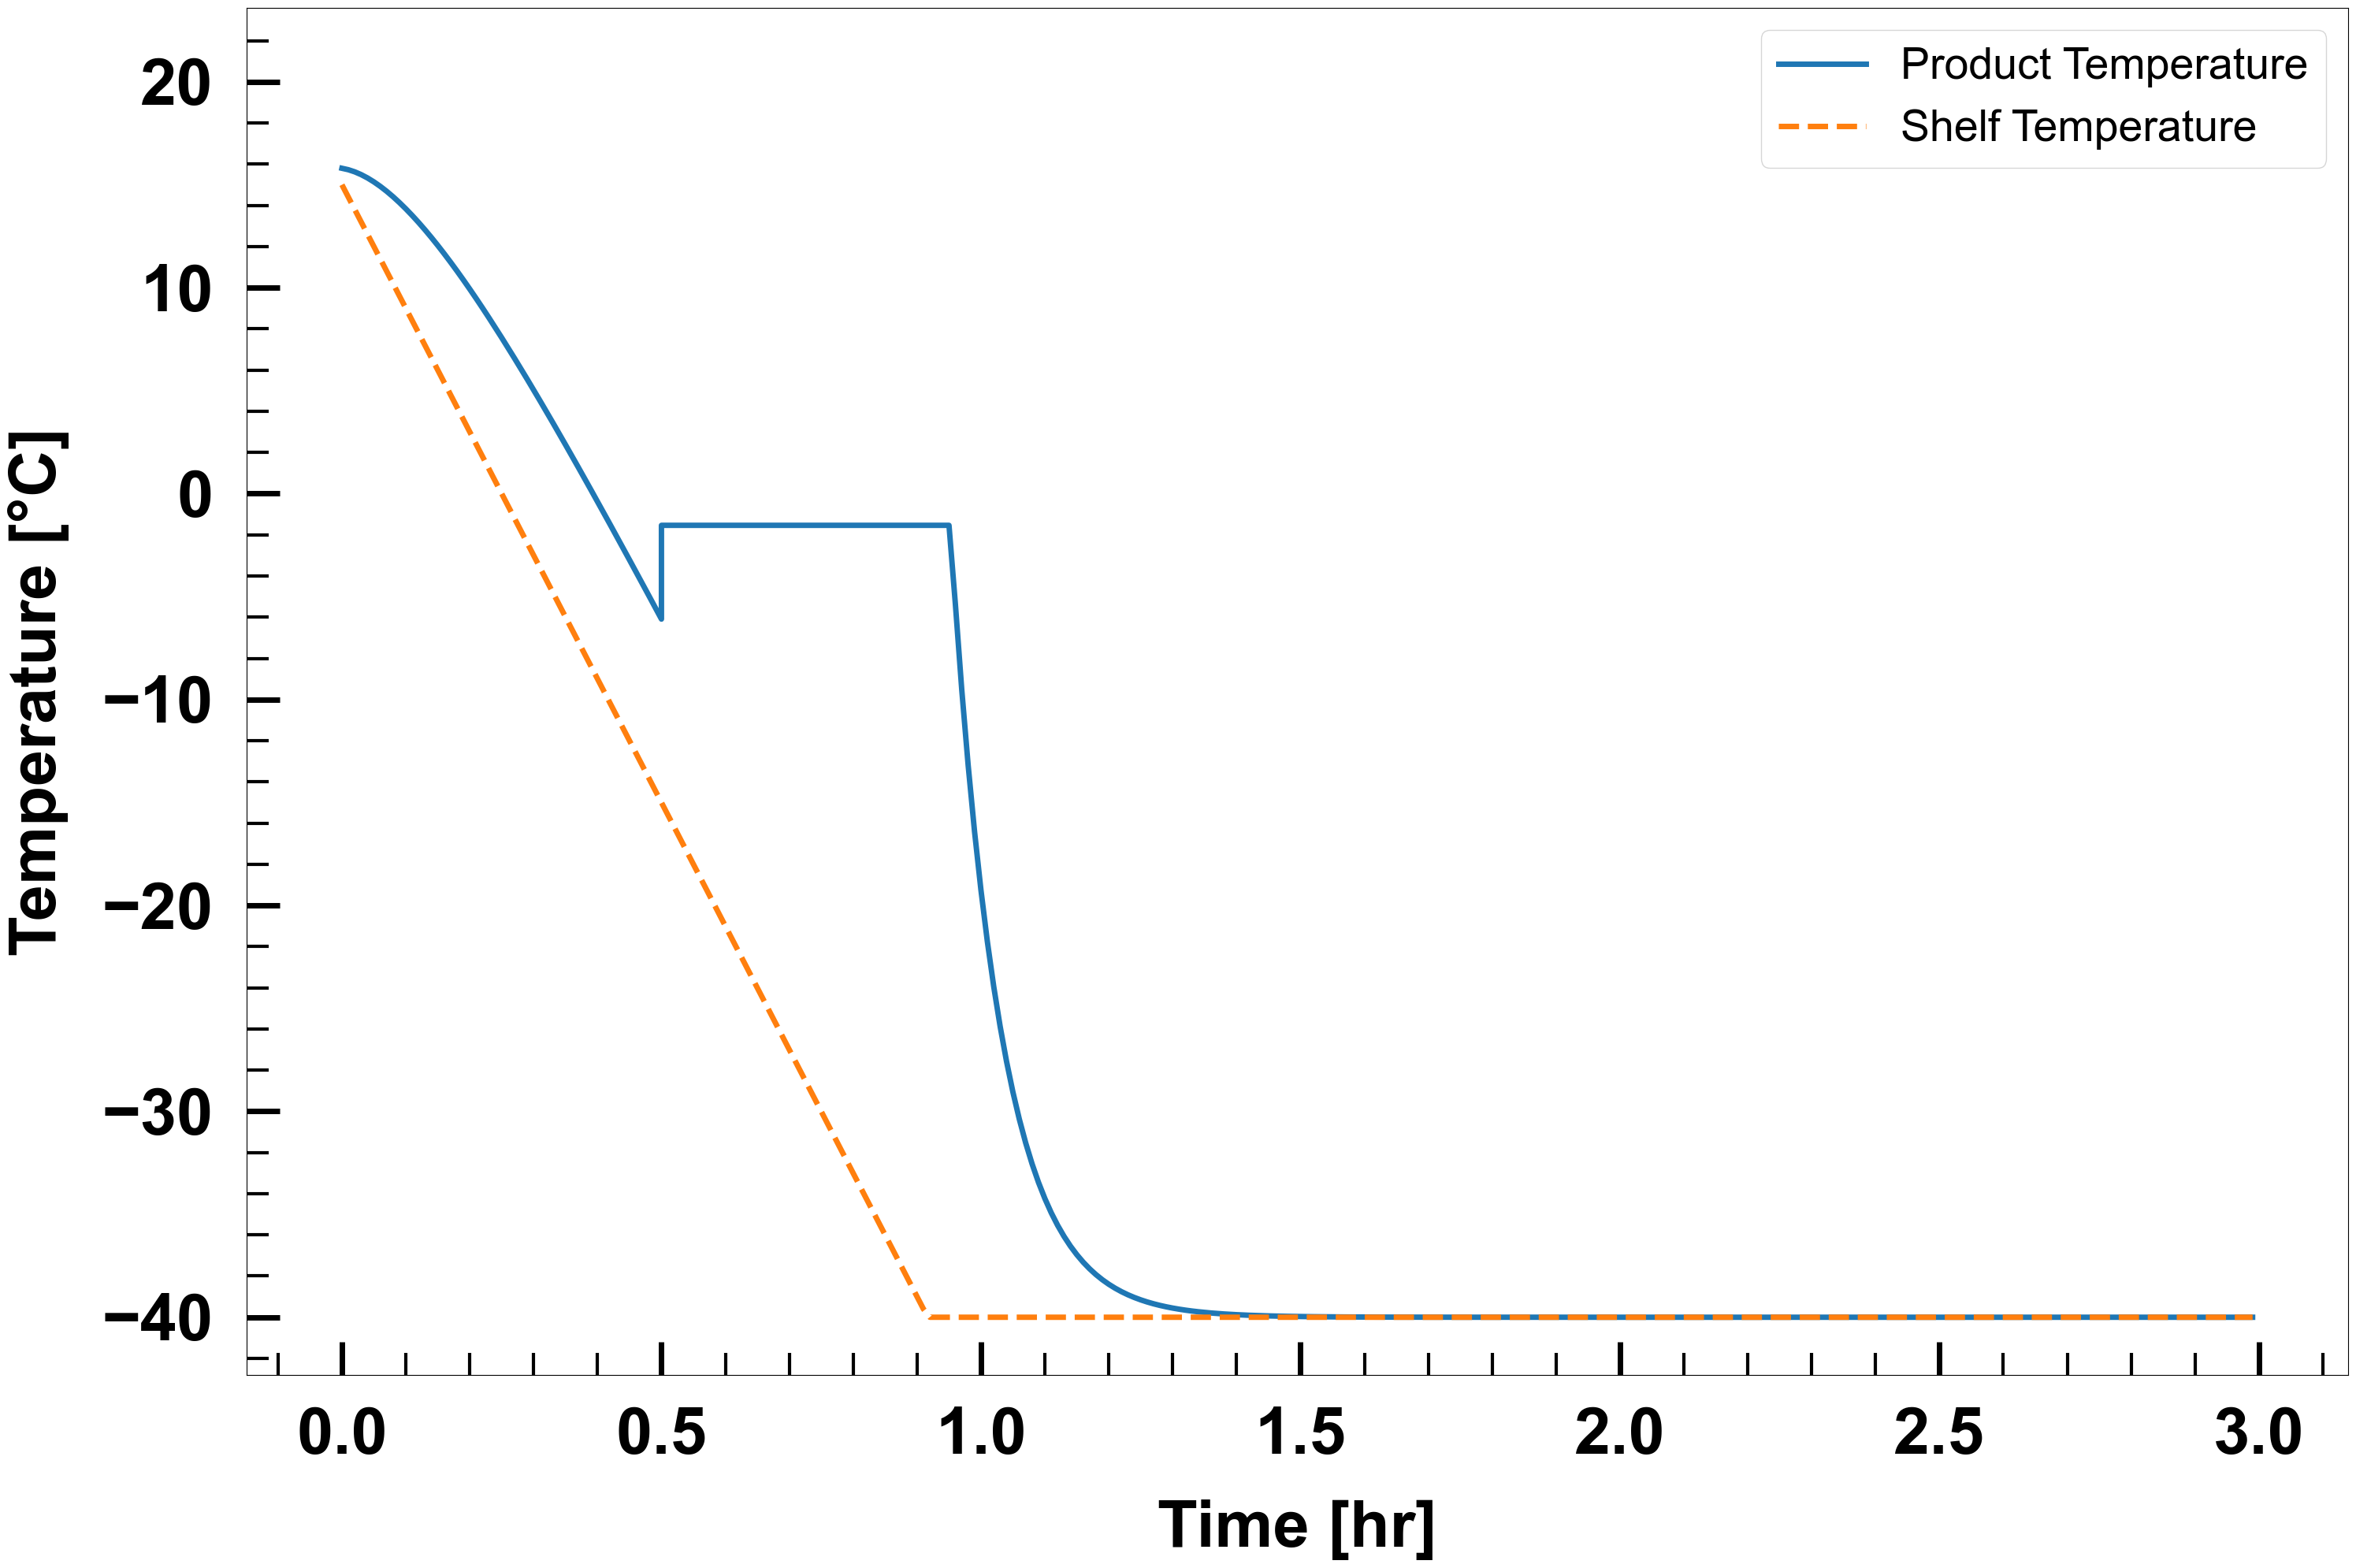

In [ ]:
# Figure dimensions
figwidth = 30
figheight = 20
# Line width
lineWidth = 5
# Font family
plt.rcParams['font.family'] = 'Arial'

# Plot product and shelf temperature vs time
fig, ax = plt.subplots(figsize=(figwidth, figheight))

ax.plot(
    output_table[:, 0],  # Time [hr]
    output_table[:, 2],  # Product Temperature [°C]
    linewidth=lineWidth,
    label='Product Temperature'
)

ax.plot(
    output_table[:, 0],  # Time [hr]
    output_table[:, 1],  # Shelf Temperature [°C]
    linewidth=lineWidth,
    label='Shelf Temperature',
    linestyle='--'
)

plot_styling.axis_style_temperature(ax)

plt.legend(fontsize=40,loc='best')
ll,ul = ax.get_ylim()
ax.set_ylim([ll,ul+5.0])
plt.tight_layout()